In [0]:
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from mlflow import MlflowClient

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [0]:
mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow registry URI:", mlflow.get_registry_uri())

MLflow tracking URI: databricks
MLflow registry URI: databricks-uc


In [0]:
DATA_DIRECTORY = "/Volumes/workspace/default/football_data"

TEST_PATH = (
    f"{DATA_DIRECTORY}/football_test.csv"
)

CHAMPION_INFO_PATH = (
    f"{DATA_DIRECTORY}/champion_run_info.csv"
)

REGISTRATION_INFO_PATH = (
    f"{DATA_DIRECTORY}/champion_registration_info.csv"
)

INFERENCE_RESULTS_PATH = (
    f"{DATA_DIRECTORY}/baseline_champion_inference_results.csv"
)

INFERENCE_SUMMARY_PATH = (
    f"{DATA_DIRECTORY}/baseline_champion_inference_summary.csv"
)

PREDICTION_SAMPLE_PATH = (
    f"{DATA_DIRECTORY}/baseline_champion_prediction_sample.csv"
)

REGISTERED_MODEL_NAME = (
    "workspace.default.football_match_result_model"
)

CHAMPION_ALIAS = "champion"

CHAMPION_ALIAS_MODEL_URI = (
    f"models:/{REGISTERED_MODEL_NAME}"
    f"@{CHAMPION_ALIAS}"
)

TARGET_COLUMN = "match_result"

print("Registered model:", REGISTERED_MODEL_NAME)
print("Alias:", CHAMPION_ALIAS)
print("Alias model URI:", CHAMPION_ALIAS_MODEL_URI)

Registered model: workspace.default.football_match_result_model
Alias: champion
Alias model URI: models:/workspace.default.football_match_result_model@champion


In [0]:
required_files = [
    TEST_PATH,
    CHAMPION_INFO_PATH,
    REGISTRATION_INFO_PATH
]

missing_files = [
    file_path
    for file_path in required_files
    if not os.path.exists(file_path)
]

assert not missing_files, (
    "The following required files are missing: "
    f"{missing_files}"
)

print("All required files are available.")

All required files are available.


In [0]:
champion_info_df = pd.read_csv(
    CHAMPION_INFO_PATH
)

registration_info_df = pd.read_csv(
    REGISTRATION_INFO_PATH
)

print("Champion run information:")
display(champion_info_df)

print("Champion registration information:")
display(registration_info_df)

Champion run information:


model_role,algorithm,run_id,model_uri,primary_metric,primary_metric_value,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,training_rows,testing_rows,training_time_seconds,max_depth,min_samples_split,min_samples_leaf,class_weight,removed_columns_path,registration_status,alias_status,registered_model_name,registered_model_version,registered_model_alias,alias_model_uri
champion,DecisionTreeClassifier,36362b3ba7c6483f8f3f3e9d22c555da,models:/m-7f4fd69605ed465f9a37b8737f96456c,test_f1_macro,0.3407115240453506,0.35575,0.5227480171428843,0.4249912752465563,0.3407115240453506,0.3219326636027983,15999,4000,0.1623985767364502,3,20,10,balanced,/Volumes/workspace/default/football_data/champion_removed_columns.json,READY,assigned,workspace.default.football_match_result_model,2,champion,models:/workspace.default.football_match_result_model@champion


Champion registration information:


registered_model_name,registered_model_version,alias,alias_model_uri,algorithm,run_id,source_model_uri,primary_metric,primary_metric_value,registration_status,alias_status,model_role,previous_champion_version,previous_champion_run_id
workspace.default.football_match_result_model,2,champion,models:/workspace.default.football_match_result_model@champion,DecisionTreeClassifier,36362b3ba7c6483f8f3f3e9d22c555da,models:/m-7f4fd69605ed465f9a37b8737f96456c,test_f1_macro,0.3407115240453506,READY,assigned,champion,1,59ac34bdab614aa0b3ee63b9a935f941


In [0]:
assert len(champion_info_df) == 1, (
    "champion_run_info.csv must contain exactly one row."
)

assert len(registration_info_df) == 1, (
    "champion_registration_info.csv must contain exactly one row."
)

required_champion_columns = [
    "algorithm",
    "run_id",
    "primary_metric",
    "primary_metric_value",
    "registered_model_name",
    "registered_model_version",
    "registered_model_alias",
    "alias_model_uri"
]

missing_columns = [
    column
    for column in required_champion_columns
    if column not in champion_info_df.columns
]

assert not missing_columns, (
    "Missing Champion metadata columns: "
    f"{missing_columns}"
)

print("Champion metadata validated successfully.")

Champion metadata validated successfully.


In [0]:
champion_record = champion_info_df.iloc[0]

expected_algorithm = str(
    champion_record["algorithm"]
)

expected_run_id = str(
    champion_record["run_id"]
)

expected_model_version = str(
    champion_record["registered_model_version"]
)

expected_alias = str(
    champion_record["registered_model_alias"]
)

expected_macro_f1 = float(
    champion_record["primary_metric_value"]
)

expected_model_name = str(
    champion_record["registered_model_name"]
)

print("Expected algorithm:", expected_algorithm)
print("Expected run ID:", expected_run_id)
print("Expected model version:", expected_model_version)
print("Expected alias:", expected_alias)
print("Expected model name:", expected_model_name)

print(
    "Expected Macro F1:",
    round(expected_macro_f1, 4)
)

Expected algorithm: DecisionTreeClassifier
Expected run ID: 36362b3ba7c6483f8f3f3e9d22c555da
Expected model version: 2
Expected alias: champion
Expected model name: workspace.default.football_match_result_model
Expected Macro F1: 0.3407


In [0]:
assert expected_algorithm == "DecisionTreeClassifier", (
    "Notebook 5 expected the baseline Decision Tree Champion, "
    f"but found: {expected_algorithm}"
)

assert expected_alias == CHAMPION_ALIAS

assert expected_model_name == REGISTERED_MODEL_NAME

print(
    "The saved metadata identifies the expected "
    "Decision Tree Champion."
)

The saved metadata identifies the expected Decision Tree Champion.


In [0]:
client = MlflowClient()

print("MLflow client created successfully.")

MLflow client created successfully.


In [0]:
alias_model_version = (
    client.get_model_version_by_alias(
        name=REGISTERED_MODEL_NAME,
        alias=CHAMPION_ALIAS
    )
)

resolved_version = str(
    alias_model_version.version
)

resolved_run_id = str(
    alias_model_version.run_id
)

resolved_status = str(
    alias_model_version.status
)

resolved_aliases = list(
    alias_model_version.aliases
)

print("Alias resolution results:")
print("Model name:", alias_model_version.name)
print("Version:", resolved_version)
print("Run ID:", resolved_run_id)
print("Status:", resolved_status)
print("Aliases:", resolved_aliases)

Alias resolution results:
Model name: workspace.default.football_match_result_model
Version: 2
Run ID: 36362b3ba7c6483f8f3f3e9d22c555da
Status: READY
Aliases: ['champion']


In [0]:
assert resolved_version == expected_model_version, (
    "The champion alias points to a different model version. "
    f"Expected {expected_model_version}, "
    f"but resolved {resolved_version}."
)

assert resolved_run_id == expected_run_id, (
    "The resolved run ID does not match "
    "the Decision Tree Champion run ID."
)

assert CHAMPION_ALIAS in resolved_aliases, (
    "The resolved model version does not contain "
    "the champion alias."
)

assert resolved_status == "READY", (
    f"The model version is not READY. Status: {resolved_status}"
)

print(
    "Alias verification completed successfully."
)

Alias verification completed successfully.


In [0]:
print("Model-version description:")
print(alias_model_version.description)

print("\nModel-version tags:")

for tag_name, tag_value in (
    alias_model_version.tags.items()
):
    print(f"{tag_name}: {tag_value}")
model_tags = alias_model_version.tags

if "algorithm" in model_tags:
    assert (
        model_tags["algorithm"]
        == "DecisionTreeClassifier"
    )

if "model_role" in model_tags:
    assert model_tags["model_role"] == "champion"

print("Model-version tag validation completed.")    

Model-version description:


Model-version tags:
algorithm: DecisionTreeClassifier
model_role: champion
model_stage: initial_baseline
primary_metric: test_f1_macro
primary_metric_value: 0.3407115240453506
promotion_status: current_champion
registration_notebook: 04_Champion_Registration
workflow: champion_challenger
workflow_version: version_2
Model-version tag validation completed.


In [0]:
test_df = pd.read_csv(
    TEST_PATH
)

print("Test dataset shape:", test_df.shape)
print("Testing rows:", len(test_df))

display(test_df.head())

Test dataset shape: (4000, 58)
Testing rows: 4000


Country,League,home_team,away_team,season_year,expected_goals_xg_home,expected_goals_xg_host,Ball_Possession_Home,Ball_Possession_Host,Goal_Attempts_Home,Goal_Attempts_Host,Shots_on_Goal_Home,Shots_on_Goal_Host,Shots_off_Goal_Home,Shots_off_Goal_Host,Blocked_Shots_Home,Blocked_Shots_Host,Free_Kicks_Home,Free_Kicks_Host,Corner_Kicks_Home,Corner_Kicks_Host,Offsides_Home,Offsides_Host,Throw_ins_Home,Throw_ins_Host,Goalkeeper_Saves_Home,Goalkeeper_Saves_Host,Fouls_Home,Fouls_Host,Red_Cards_Home,Red_Cards_Host,Yellow_Cards_Home,Yellow_Cards_Host,Tackles_Home,Tackles_Host,Interceptions_Home,Interceptions_Host,Clearances_Completed_Home,Clearances_Completed_Host,Total_Passes_Home,Total_Passes_Host,Completed_Passes_Home,Completed_Passes_Host,Pass_Success_per_Home,Pass_Success_per_Host,Crosses_Completed_Home,Crosses_Completed_Host,Attacks_Home,Attacks_Host,Dangerous_Attacks_Home,Dangerous_Attacks_Host,Distance_Covered_(km)_Home,Distance_Covered_(km)_Host,referee,venue,capacity,attendance,match_result
Germany,2-bundesliga,Saarbrucken,B. Monchengladbach,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Away Win
France,Ligue-2,Laval,Red Star,null,null,null,56.0,44.0,16.0,7.0,5.0,3.0,11.0,4.0,null,null,22.0,9.0,9.0,1.0,null,null,25.0,22.0,2.0,4.0,null,null,null,null,0.0,2.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Delpech R. (Fra),Stade Francis Le Basser (Laval),null,null,Draw
Italy,Serie-a,Reggina,Juventus,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Stadio Oreste Granillo (Reggio Calabria),null,null,Away Win
England,Championship,Burnley,Coventry,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Turf Moor (Burnley),null,null,Away Win
Turkey,Super-lig,Gaziantepspor,Ankaragucu,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,Home Win


In [0]:
assert TARGET_COLUMN in test_df.columns, (
    f"{TARGET_COLUMN} is missing from the test dataset."
)

assert len(test_df) == 4000, (
    f"Expected 4000 testing rows, "
    f"but found {len(test_df)}."
)

print("Test dataset validated successfully.")

Test dataset validated successfully.


In [0]:
LEAKAGE_COLUMNS = [
    "home_score",
    "away_score"
]

columns_to_exclude = [
    TARGET_COLUMN,
    *[
        column
        for column in LEAKAGE_COLUMNS
        if column in test_df.columns
    ]
]

X_test = test_df.drop(
    columns=columns_to_exclude,
    errors="ignore"
).copy()

y_test = test_df[
    TARGET_COLUMN
].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print(
    "Excluded columns:",
    columns_to_exclude
)

X_test shape: (4000, 57)
y_test shape: (4000,)
Excluded columns: ['match_result']


In [0]:
LEAKAGE_COLUMNS = [
    "home_score",
    "away_score"
]

columns_to_exclude = [
    TARGET_COLUMN,
    *[
        column
        for column in LEAKAGE_COLUMNS
        if column in test_df.columns
    ]
]

X_test = test_df.drop(
    columns=columns_to_exclude,
    errors="ignore"
).copy()

y_test = test_df[
    TARGET_COLUMN
].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print(
    "Excluded columns:",
    columns_to_exclude
)

X_test shape: (4000, 57)
y_test shape: (4000,)
Excluded columns: ['match_result']


In [0]:
inference_load_start = time.time()

champion_model = mlflow.sklearn.load_model(
    CHAMPION_ALIAS_MODEL_URI
)

model_loading_time = (
    time.time() - inference_load_start
)

print(
    "Champion loaded successfully through alias."
)

print(
    "Loaded model type:",
    type(champion_model)
)

print(
    "Model loading time:",
    round(model_loading_time, 4),
    "seconds"
)

Champion loaded successfully through alias.
Loaded model type: <class 'sklearn.pipeline.Pipeline'>
Model loading time: 6.4029 seconds


In [0]:
print("Loaded Champion pipeline:")
print(champion_model)



Loaded Champion pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['expected_goals_xg_home',
                                                   'expected_goals_xg_host',
                                                   'Ball_Possession_Home',
                                                   'Ball_Possession_Host',
                                                   'Goal_Attempts_Home',
                                                   'Goal_Attempts_Host',
                                                   'Shots_on_Goal_Home',
                                                   'Shots_on_Goal_Host',
                                                   'Shots_off_Goal_Home',
                            

In [0]:
if hasattr(champion_model, "named_steps"):

    print("\nPipeline steps:")

    for step_name, step_object in (
        champion_model.named_steps.items()
    ):
        print(
            f"{step_name}: "
            f"{type(step_object).__name__}"
        )

else:
    print(
        "The loaded object does not expose "
        "named pipeline steps."
    )


Pipeline steps:
preprocessor: ColumnTransformer
classifier: DecisionTreeClassifier


In [0]:
if hasattr(champion_model, "named_steps"):

    loaded_classifier = (
        champion_model.named_steps[
            "classifier"
        ]
    )

    loaded_classifier_name = (
        type(loaded_classifier).__name__
    )

    print(
        "Loaded classifier:",
        loaded_classifier_name
    )

    assert (
        loaded_classifier_name
        == "DecisionTreeClassifier"
    )

print(
    "Loaded model confirmed as the "
    "baseline Decision Tree Champion."
)

Loaded classifier: DecisionTreeClassifier
Loaded model confirmed as the baseline Decision Tree Champion.


In [0]:
sample_input = X_test.head(10).copy()

sample_predictions = champion_model.predict(
    sample_input
)

print("Sample predictions:")
print(sample_predictions)

assert len(sample_predictions) == 10

print("Sample inference completed successfully.")

Sample predictions:
['Draw' 'Draw' 'Draw' 'Draw' 'Draw' 'Draw' 'Away Win' 'Draw' 'Home Win'
 'Draw']
Sample inference completed successfully.


In [0]:
if hasattr(champion_model, "predict_proba"):

    sample_probabilities = (
        champion_model.predict_proba(
            sample_input
        )
    )

    print(
        "Sample probability matrix shape:",
        sample_probabilities.shape
    )

    print("\nFirst probability row:")
    print(sample_probabilities[0])

else:
    sample_probabilities = None

    print(
        "The loaded model does not expose "
        "predict_proba()."
    )

Sample probability matrix shape: (10, 3)

First probability row:
[0.29964992 0.36649791 0.33385217]


In [0]:
if hasattr(champion_model, "classes_"):

    model_classes = list(
        champion_model.classes_
    )

elif (
    hasattr(champion_model, "named_steps")
    and hasattr(
        champion_model.named_steps[
            "classifier"
        ],
        "classes_"
    )
):

    model_classes = list(
        champion_model.named_steps[
            "classifier"
        ].classes_
    )

else:
    model_classes = sorted(
        y_test.unique().tolist()
    )

print("Model classes:")
print(model_classes)

Model classes:
['Away Win', 'Draw', 'Home Win']


In [0]:
inference_start_time = time.time()

champion_predictions = champion_model.predict(
    X_test
)

inference_time_seconds = (
    time.time() - inference_start_time
)

print("Full test inference completed.")

print(
    "Number of predictions:",
    len(champion_predictions)
)

print(
    "Inference time:",
    round(inference_time_seconds, 4),
    "seconds"
)

Full test inference completed.
Number of predictions: 4000
Inference time: 0.0262 seconds


In [0]:
assert len(champion_predictions) == len(X_test)

assert len(champion_predictions) == 4000

print("Prediction count validated successfully.")

Prediction count validated successfully.


In [0]:
if hasattr(champion_model, "predict_proba"):

    champion_probabilities = (
        champion_model.predict_proba(
            X_test
        )
    )

    print(
        "Probability matrix shape:",
        champion_probabilities.shape
    )

    assert (
        champion_probabilities.shape[0]
        == len(X_test)
    )

    assert (
        champion_probabilities.shape[1]
        == len(model_classes)
    )

else:
    champion_probabilities = None

    print(
        "Probability output is not available."
    )

Probability matrix shape: (4000, 3)


In [0]:
if champion_probabilities is not None:

    probability_row_sums = (
        champion_probabilities.sum(axis=1)
    )

    assert np.allclose(
        probability_row_sums,
        1.0,
        atol=1e-6
    ), (
        "Some prediction probabilities "
        "do not sum to 1."
    )

    assert np.all(
        champion_probabilities >= 0
    )

    assert np.all(
        champion_probabilities <= 1
    )

    print(
        "Prediction probabilities validated."
    )

Prediction probabilities validated.


In [0]:
def calculate_metrics(
    y_true,
    y_pred
):
    return {
        "test_accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "test_precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [0]:
inference_metrics = calculate_metrics(
    y_test,
    champion_predictions
)

print("=" * 60)
print("BASELINE CHAMPION INFERENCE METRICS")
print("=" * 60)

for metric_name, metric_value in (
    inference_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

BASELINE CHAMPION INFERENCE METRICS
test_accuracy: 0.3558
test_precision_macro: 0.5227
test_recall_macro: 0.4250
test_f1_macro: 0.3407
test_f1_weighted: 0.3219


In [0]:
inference_macro_f1 = float(
    inference_metrics["test_f1_macro"]
)

metric_difference = abs(
    inference_macro_f1
    - expected_macro_f1
)

print(
    "Notebook 3 Macro F1:",
    round(expected_macro_f1, 6)
)

print(
    "Notebook 5 inference Macro F1:",
    round(inference_macro_f1, 6)
)

print(
    "Absolute difference:",
    round(metric_difference, 10)
)

assert round(
    inference_macro_f1,
    4
) == round(
    expected_macro_f1,
    4
)

Notebook 3 Macro F1: 0.340712
Notebook 5 inference Macro F1: 0.340712
Absolute difference: 0.0


In [0]:
METRIC_TOLERANCE = 1e-8

assert metric_difference <= METRIC_TOLERANCE, (
    "The inference Macro F1 does not match "
    "the training notebook result."
)

print(
    "Inference metrics match the original "
    "Champion metrics."
)

Inference metrics match the original Champion metrics.


In [0]:
classification_report_text = (
    classification_report(
        y_test,
        champion_predictions,
        zero_division=0
    )
)

print(
    "Baseline Champion Classification Report"
)

print(classification_report_text)

Baseline Champion Classification Report
              precision    recall  f1-score   support

    Away Win       0.57      0.27      0.37      1223
        Draw       0.27      0.86      0.41       963
    Home Win       0.73      0.15      0.24      1814

    accuracy                           0.36      4000
   macro avg       0.52      0.42      0.34      4000
weighted avg       0.57      0.36      0.32      4000



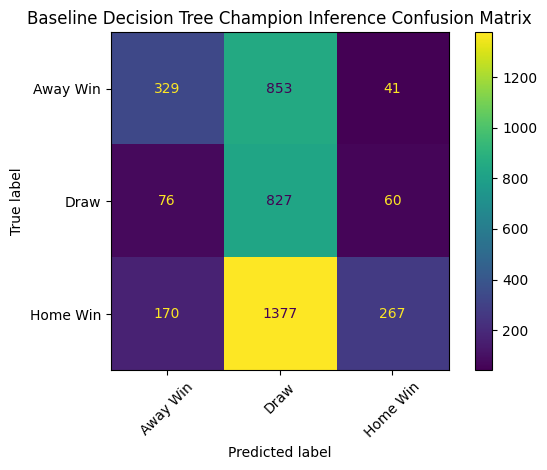

In [0]:
class_labels = sorted(
    y_test.unique().tolist()
)

confusion_values = confusion_matrix(
    y_test,
    champion_predictions,
    labels=class_labels
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_values,
    display_labels=class_labels
)

confusion_display.plot(
    values_format="d"
)

plt.title(
    "Baseline Decision Tree Champion "
    "Inference Confusion Matrix"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
inference_results_df = pd.DataFrame(
    {
        "actual_result": (
            y_test.reset_index(drop=True)
        ),
        "predicted_result": (
            pd.Series(champion_predictions)
        ),
        "prediction_correct": (
            y_test.reset_index(drop=True)
            == pd.Series(champion_predictions)
        )
    }
)

display(inference_results_df.head(20))

actual_result,predicted_result,prediction_correct
Away Win,Draw,false
Draw,Draw,true
Away Win,Draw,false
Away Win,Draw,false
Home Win,Draw,false
Away Win,Draw,false
Home Win,Away Win,false
Draw,Draw,true
Home Win,Home Win,true
Draw,Draw,true


In [0]:
if champion_probabilities is not None:

    for class_index, class_name in enumerate(
        model_classes
    ):

        safe_class_name = (
            str(class_name)
            .strip()
            .lower()
            .replace(" ", "_")
            .replace("-", "_")
        )

        probability_column = (
            f"probability_{safe_class_name}"
        )

        inference_results_df[
            probability_column
        ] = champion_probabilities[
            :,
            class_index
        ]

print(
    "Inference result columns:"
)

print(
    inference_results_df.columns.tolist()
)

Inference result columns:
['actual_result', 'predicted_result', 'prediction_correct', 'probability_away_win', 'probability_draw', 'probability_home_win']


In [0]:
if champion_probabilities is not None:

    inference_results_df[
        "prediction_confidence"
    ] = np.max(
        champion_probabilities,
        axis=1
    )

    inference_results_df[
        "low_confidence_prediction"
    ] = (
        inference_results_df[
            "prediction_confidence"
        ]
        < 0.50
    )

    print(
        "Average prediction confidence:",
        round(
            inference_results_df[
                "prediction_confidence"
            ].mean(),
            4
        )
    )

    print(
        "Low-confidence predictions:",
        int(
            inference_results_df[
                "low_confidence_prediction"
            ].sum()
        )
    )

Average prediction confidence: 0.4284
Low-confidence predictions: 3057


In [0]:
sample_size = 20

prediction_sample_df = (
    inference_results_df.head(
        sample_size
    ).copy()
)

display(prediction_sample_df)

actual_result,predicted_result,prediction_correct,probability_away_win,probability_draw,probability_home_win,prediction_confidence,low_confidence_prediction
Away Win,Draw,false,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Draw,Draw,true,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Away Win,Draw,false,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Away Win,Draw,false,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Home Win,Draw,false,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Away Win,Draw,false,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Home Win,Away Win,false,0.6724303944132058,0.004348858001600643,0.3232207475851894,0.6724303944132058,false
Draw,Draw,true,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true
Home Win,Home Win,true,0.13147649158246544,0.2995311785385943,0.5689923298789241,0.5689923298789241,false
Draw,Draw,true,0.29964991718094613,0.3664979144915462,0.33385216832753944,0.3664979144915462,true


In [0]:
prediction_sample_df.to_csv(
    PREDICTION_SAMPLE_PATH,
    index=False
)

print(
    "Prediction sample saved to:",
    PREDICTION_SAMPLE_PATH
)

Prediction sample saved to: /Volumes/workspace/default/football_data/baseline_champion_prediction_sample.csv


In [0]:
inference_results_df.to_csv(
    INFERENCE_RESULTS_PATH,
    index=False
)

print(
    "Complete inference results saved to:"
)

print(INFERENCE_RESULTS_PATH)

Complete inference results saved to:
/Volumes/workspace/default/football_data/baseline_champion_inference_results.csv


In [0]:
correct_prediction_count = int(
    inference_results_df[
        "prediction_correct"
    ].sum()
)

incorrect_prediction_count = int(
    (
        ~inference_results_df[
            "prediction_correct"
        ]
    ).sum()
)

if champion_probabilities is not None:

    average_confidence = float(
        inference_results_df[
            "prediction_confidence"
        ].mean()
    )

else:
    average_confidence = np.nan

inference_summary_df = pd.DataFrame(
    [
        {
            "model_role": "champion",
            "algorithm": expected_algorithm,
            "registered_model_name": (
                REGISTERED_MODEL_NAME
            ),
            "registered_model_version": (
                resolved_version
            ),
            "registered_model_alias": (
                CHAMPION_ALIAS
            ),
            "alias_model_uri": (
                CHAMPION_ALIAS_MODEL_URI
            ),
            "run_id": resolved_run_id,
            "testing_rows": len(X_test),
            "prediction_count": len(
                champion_predictions
            ),
            "correct_predictions": (
                correct_prediction_count
            ),
            "incorrect_predictions": (
                incorrect_prediction_count
            ),
            "test_accuracy": (
                inference_metrics[
                    "test_accuracy"
                ]
            ),
            "test_precision_macro": (
                inference_metrics[
                    "test_precision_macro"
                ]
            ),
            "test_recall_macro": (
                inference_metrics[
                    "test_recall_macro"
                ]
            ),
            "test_f1_macro": (
                inference_metrics[
                    "test_f1_macro"
                ]
            ),
            "test_f1_weighted": (
                inference_metrics[
                    "test_f1_weighted"
                ]
            ),
            "average_prediction_confidence": (
                average_confidence
            ),
            "model_loading_time_seconds": (
                model_loading_time
            ),
            "inference_time_seconds": (
                inference_time_seconds
            ),
            "metric_matches_training": (
                round(
                    inference_macro_f1,
                    4
                )
                == round(
                    expected_macro_f1,
                    4
                )
            ),
            "alias_verification": "PASSED"
        }
    ]
)

display(inference_summary_df)

model_role,algorithm,registered_model_name,registered_model_version,registered_model_alias,alias_model_uri,run_id,testing_rows,prediction_count,correct_predictions,incorrect_predictions,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,average_prediction_confidence,model_loading_time_seconds,inference_time_seconds,metric_matches_training,alias_verification
champion,DecisionTreeClassifier,workspace.default.football_match_result_model,2,champion,models:/workspace.default.football_match_result_model@champion,36362b3ba7c6483f8f3f3e9d22c555da,4000,4000,1423,2577,0.35575,0.5227480171428843,0.42499127524655633,0.34071152404535066,0.3219326636027983,0.428417300343556,6.402911901473999,0.026215076446533203,true,PASSED


In [0]:
inference_summary_df.to_csv(
    INFERENCE_SUMMARY_PATH,
    index=False
)

print(
    "Inference summary saved to:"
)

print(INFERENCE_SUMMARY_PATH)

Inference summary saved to:
/Volumes/workspace/default/football_data/baseline_champion_inference_summary.csv


In [0]:
required_output_files = [
    INFERENCE_RESULTS_PATH,
    INFERENCE_SUMMARY_PATH,
    PREDICTION_SAMPLE_PATH
]

missing_output_files = [
    file_path
    for file_path in required_output_files
    if not os.path.exists(file_path)
]

assert not missing_output_files, (
    "The following inference outputs "
    f"were not saved: {missing_output_files}"
)

saved_results_df = pd.read_csv(
    INFERENCE_RESULTS_PATH
)

saved_summary_df = pd.read_csv(
    INFERENCE_SUMMARY_PATH
)

saved_sample_df = pd.read_csv(
    PREDICTION_SAMPLE_PATH
)

assert len(saved_results_df) == 4000
assert len(saved_summary_df) == 1
assert len(saved_sample_df) == 20

print("Saved inference files validated successfully.")

Saved inference files validated successfully.


In [0]:
assert (
    CHAMPION_ALIAS_MODEL_URI
    == (
        "models:/"
        "workspace.default."
        "football_match_result_model"
        "@champion"
    )
)

assert resolved_version == expected_model_version
assert resolved_run_id == expected_run_id
assert expected_algorithm == "DecisionTreeClassifier"

print(
    "The model was loaded entirely through "
    "the champion alias."
)

The model was loaded entirely through the champion alias.


In [0]:
print("=" * 70)
print("NOTEBOOK 5 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "Loaded model:",
    REGISTERED_MODEL_NAME
)

print(
    "Loaded through alias:",
    CHAMPION_ALIAS
)

print(
    "Resolved version:",
    resolved_version
)

print(
    "Algorithm:",
    expected_algorithm
)

print(
    "Run ID:",
    resolved_run_id
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Prediction count:",
    len(champion_predictions)
)

print(
    "Accuracy:",
    round(
        inference_metrics[
            "test_accuracy"
        ],
        4
    )
)

print(
    "Macro F1:",
    round(
        inference_metrics[
            "test_f1_macro"
        ],
        4
    )
)

print(
    "Metrics match Notebook 3:",
    round(
        inference_macro_f1,
        4
    )
    == round(
        expected_macro_f1,
        4
    )
)

print(
    "Alias verification:",
    "PASSED"
)

print(
    "Inference results:",
    INFERENCE_RESULTS_PATH
)

print(
    "Inference summary:",
    INFERENCE_SUMMARY_PATH
)

print(
    "Result: The registered Decision Tree "
    "Champion successfully generated "
    "predictions through the champion alias."
)

NOTEBOOK 5 COMPLETED SUCCESSFULLY
Loaded model: workspace.default.football_match_result_model
Loaded through alias: champion
Resolved version: 2
Algorithm: DecisionTreeClassifier
Run ID: 36362b3ba7c6483f8f3f3e9d22c555da
Testing rows: 4000
Prediction count: 4000
Accuracy: 0.3558
Macro F1: 0.3407
Metrics match Notebook 3: True
Alias verification: PASSED
Inference results: /Volumes/workspace/default/football_data/baseline_champion_inference_results.csv
Inference summary: /Volumes/workspace/default/football_data/baseline_champion_inference_summary.csv
Result: The registered Decision Tree Champion successfully generated predictions through the champion alias.
